In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

PATH = "C:/Users/shata/OneDrive/Desktop/Buildinga job market intelligence platform/"


analyst = pd.read_csv(PATH + "data/processed/analyst_clean.csv")
salary = pd.read_csv(PATH + "data/processed/salaries_clean.csv")
naukri = pd.read_csv(PATH + "data/processed/naukri_clean.csv")

sns.set_theme(style="whitegrid", palette="muted")

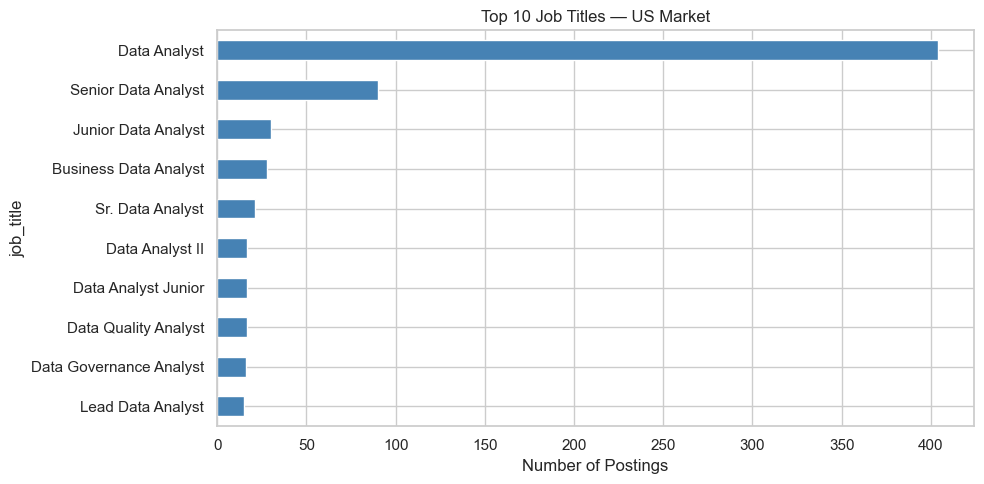

✅ Chart 1 saved


In [5]:
# ══════════════════════════════════════════════════════════
# CHART 1 — Top 10 Job Titles (US Market)
# ══════════════════════════════════════════════════════════
plt.figure(figsize=(10, 5))
analyst['job_title'].value_counts().head(10).sort_values().plot(kind='barh', color='steelblue')
plt.title("Top 10 Job Titles — US Market")
plt.xlabel("Number of Postings")
plt.tight_layout()
plt.savefig(PATH + "screenshots/chart1_top_titles.png", dpi=150)
plt.show()
print("✅ Chart 1 saved")


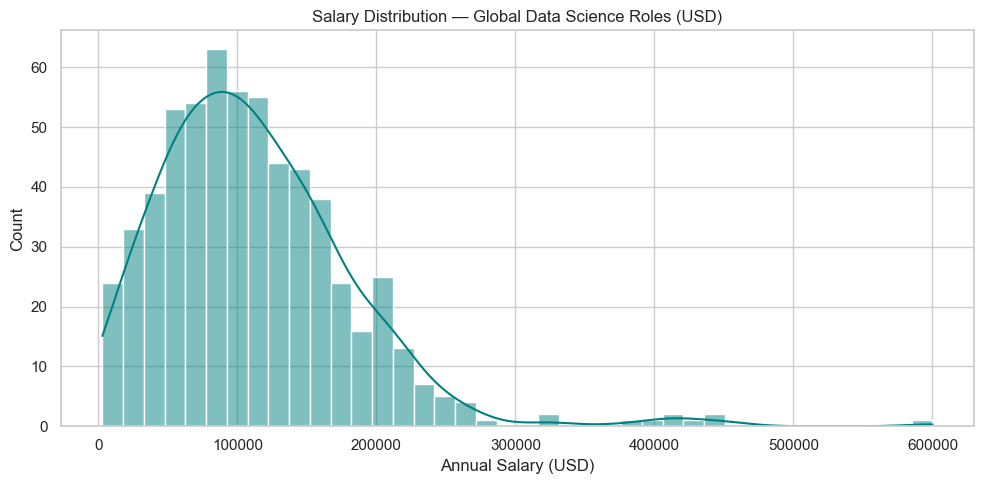

✅ Chart 2 saved


In [6]:

# ══════════════════════════════════════════════════════════
# CHART 2 — Salary Distribution (Global DS Roles)
# ══════════════════════════════════════════════════════════
plt.figure(figsize=(10, 5))
sns.histplot(salary['salary_avg'], bins=40, kde=True, color='teal')
plt.title("Salary Distribution — Global Data Science Roles (USD)")
plt.xlabel("Annual Salary (USD)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(PATH + "screenshots/chart2_salary_dist.png", dpi=150)
plt.show()
print("✅ Chart 2 saved")

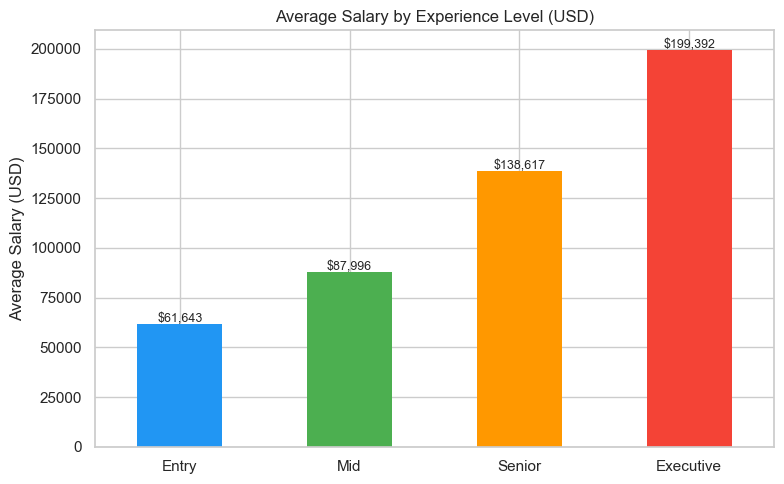

✅ Chart 3 saved


In [7]:

# ══════════════════════════════════════════════════════════
# CHART 3 — Average Salary by Experience Level
# ══════════════════════════════════════════════════════════
plt.figure(figsize=(8, 5))
order = ['Entry', 'Mid', 'Senior', 'Executive']
exp_salary = salary.groupby('experience_level')['salary_avg'].mean().reindex(order)
colors = ['#2196F3', '#4CAF50', '#FF9800', '#F44336']
exp_salary.plot(kind='bar', color=colors, edgecolor='none')
plt.title("Average Salary by Experience Level (USD)")
plt.ylabel("Average Salary (USD)")
plt.xlabel("")
plt.xticks(rotation=0)
for i, val in enumerate(exp_salary):
    plt.text(i, val + 1000, f"${val:,.0f}", ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(PATH + "screenshots/chart3_salary_experience.png", dpi=150)
plt.show()
print("✅ Chart 3 saved")


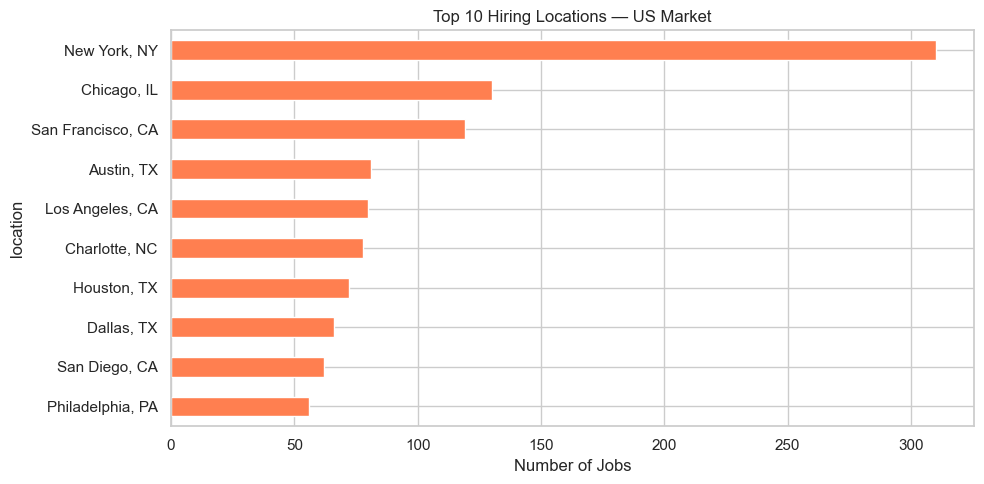

✅ Chart 4 saved


In [8]:

# ══════════════════════════════════════════════════════════
# CHART 4 — Top 10 Hiring Locations (US)
# ══════════════════════════════════════════════════════════
plt.figure(figsize=(10, 5))
analyst['location'].value_counts().head(10).sort_values().plot(kind='barh', color='coral')
plt.title("Top 10 Hiring Locations — US Market")
plt.xlabel("Number of Jobs")
plt.tight_layout()
plt.savefig(PATH + "screenshots/chart4_top_locations.png", dpi=150)
plt.show()
print("✅ Chart 4 saved")

C:\Users\shata\AppData\Local\Temp\ipykernel_25704\3839949412.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=skill_df, x='Count', y='Skill', palette='viridis',legend=False)


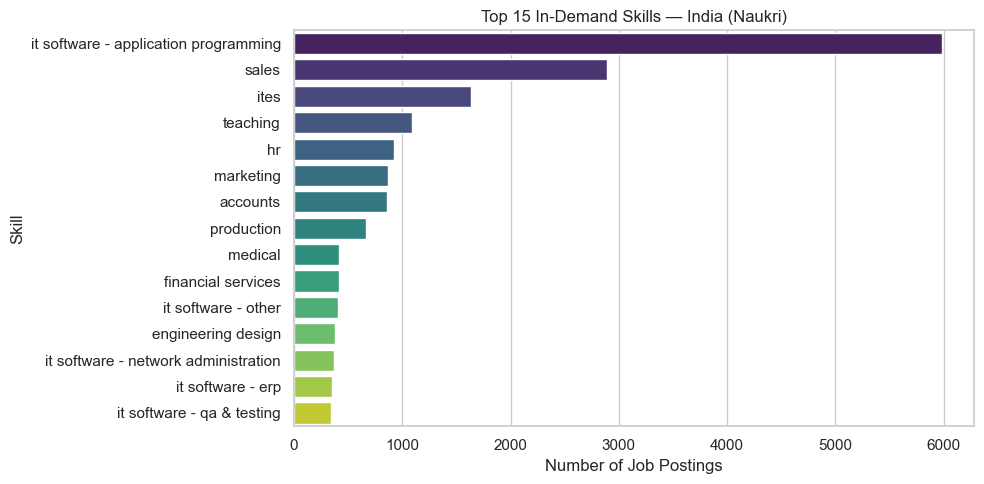

✅ Chart 5 saved


In [12]:

# ══════════════════════════════════════════════════════════
# CHART 5 — Top 15 In-Demand Skills (India — Naukri)
# ══════════════════════════════════════════════════════════
skill_series = naukri['skills'].dropna().str.lower().str.split(',')
all_skills = Counter(
    skill.strip() for sublist in skill_series for skill in sublist
    if skill.strip() != 'not listed'
)
skill_df = pd.DataFrame(all_skills.most_common(15), columns=['Skill', 'Count'])

plt.figure(figsize=(10, 5))
sns.barplot(data=skill_df, x='Count', y='Skill', palette='viridis',legend=False)
plt.title("Top 15 In-Demand Skills — India (Naukri)")
plt.xlabel("Number of Job Postings")
plt.tight_layout()
plt.savefig(PATH + "screenshots/chart5_top_skills_india.png", dpi=150)
plt.show()
print("✅ Chart 5 saved")


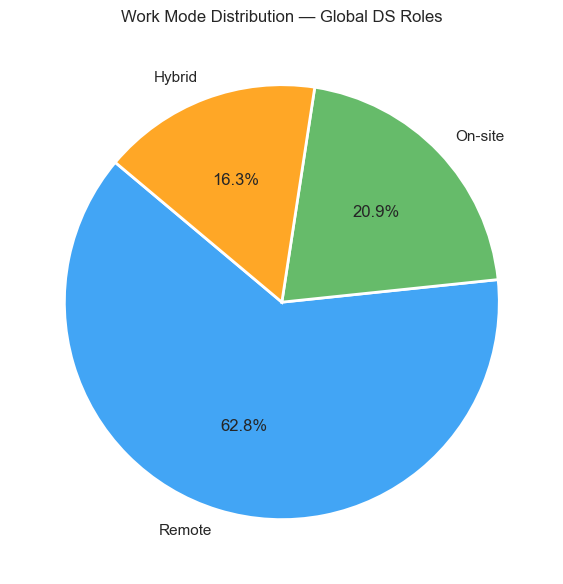

✅ Chart 6 saved


In [13]:
# ══════════════════════════════════════════════════════════
# CHART 6 — Remote vs Hybrid vs On-site
# ══════════════════════════════════════════════════════════
plt.figure(figsize=(6, 6))
work_counts = salary['work_mode'].value_counts()
plt.pie(work_counts, labels=work_counts.index, autopct='%1.1f%%',
        colors=['#42A5F5', '#66BB6A', '#FFA726'],
        startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
plt.title("Work Mode Distribution — Global DS Roles")
plt.tight_layout()
plt.savefig(PATH + "screenshots/chart6_work_mode.png", dpi=150)
plt.show()
print("✅ Chart 6 saved")

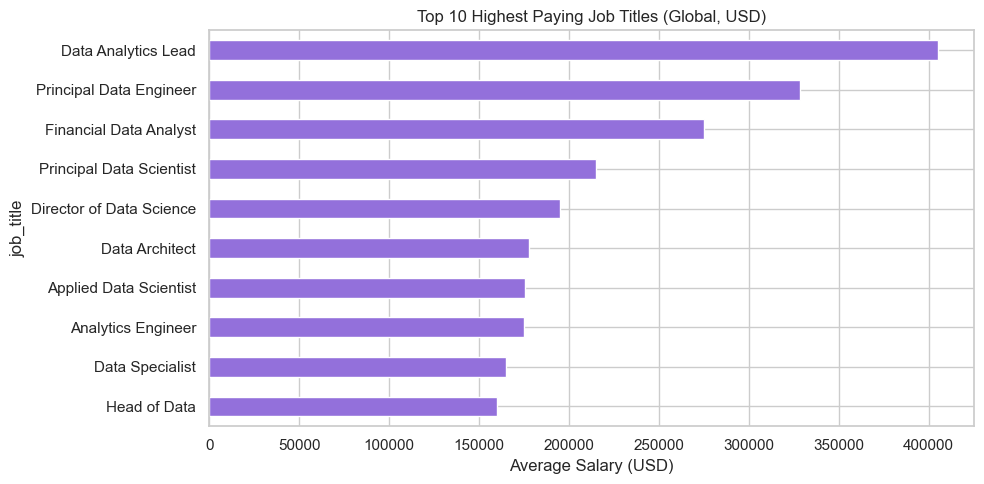

✅ Chart 7 saved


In [14]:

# ══════════════════════════════════════════════════════════
# CHART 7 — Top 10 Job Titles by Avg Salary (Global)
# ══════════════════════════════════════════════════════════
plt.figure(figsize=(10, 5))
top_titles = (salary.groupby('job_title')['salary_avg']
                 .mean()
                 .sort_values(ascending=False)
                 .head(10)
                 .sort_values())
top_titles.plot(kind='barh', color='mediumpurple')
plt.title("Top 10 Highest Paying Job Titles (Global, USD)")
plt.xlabel("Average Salary (USD)")
plt.tight_layout()
plt.savefig(PATH + "screenshots/chart7_top_paying_titles.png", dpi=150)
plt.show()
print("✅ Chart 7 saved")

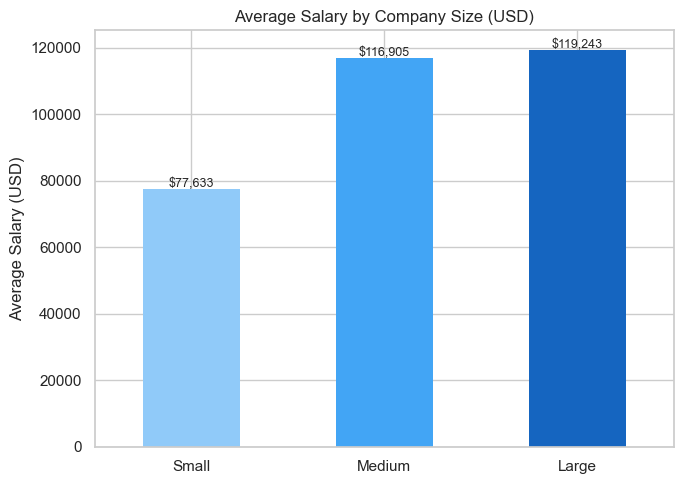

✅ Chart 8 saved


In [ ]:

# ══════════════════════════════════════════════════════════
# CHART 8 — Company Size vs Average Salary
# ══════════════════════════════════════════════════════════
plt.figure(figsize=(7, 5))
size_map = {'S': 'Small', 'M': 'Medium', 'L': 'Large'}
salary['company_size_label'] = salary['company_size'].map(size_map)
size_salary = salary.groupby('company_size_label')['salary_avg'].mean().reindex(['Small','Medium','Large'])
size_salary.plot(kind='bar', color=['#90CAF9', '#42A5F5', '#1565C0'], edgecolor='none')
plt.title("Average Salary by Company Size (USD)")
plt.ylabel("Average Salary (USD)")
plt.xlabel("")
plt.xticks(rotation=0)
for i, val in enumerate(size_salary):
    plt.text(i, val + 500, f"${val:,.0f}", ha='center', fontsize=9)
plt.tight_layout()
plt.savefig(PATH + "screenshots/chart8_company_size_salary.png", dpi=150)
plt.show()
print("✅ Chart 8 saved")


In [16]:
print("\n All 8 charts saved to screenshots/")


 All 8 charts saved to screenshots/
